In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ==========================================================
# FINAL TRAIN MIX
#
# PEDIATRIC
#   Class 0 (NORMAL)      -> 30%
#   Class 1 (PNEUMONIA)   -> 50%
#
# PNEUMONIAMNIST
#   70% stratified
#
# RSNA
#   10% stratified
#
# FINAL OUTPUT:
#   train_df
#       path
#       label
#       source
# ==========================================================

import os
import cv2
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42

# ==========================================================
# HELPER
# ==========================================================

def print_stats(name, labels):

    labels = np.array(labels)

    unique, counts = np.unique(labels, return_counts=True)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    total = len(labels)

    for u, c in zip(unique, counts):
        print(
            f"Class {u}: {c} "
            f"({100*c/total:.2f}%)"
        )

    print(f"Total Samples: {total}")


# ==========================================================
# PEDIATRIC DATASET
# ==========================================================

PED_PATH = Path(
    "/kaggle/input/datasets/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset"
)

normal_files = [
    str(x)
    for x in PED_PATH.rglob("NORMAL/*")
    if x.is_file()
]

pneumonia_files = [
    str(x)
    for x in PED_PATH.rglob("PNEUMONIA/*")
    if x.is_file()
]

print_stats(
    "PEDIATRIC ORIGINAL",
    [0] * len(normal_files)
    +
    [1] * len(pneumonia_files)
)

# ----------------------------------------------------------
# NORMAL -> 30%
# PNEUMONIA -> 50%
# ----------------------------------------------------------

ped_normal = (
    pd.Series(normal_files)
    .sample(
        frac=0.30,
        random_state=SEED
    )
    .tolist()
)

ped_pneumonia = (
    pd.Series(pneumonia_files)
    .sample(
        frac=0.50,
        random_state=SEED
    )
    .tolist()
)

pediatric_df = pd.DataFrame({

    "path":
        ped_normal
        +
        ped_pneumonia,

    "label":
        [0] * len(ped_normal)
        +
        [1] * len(ped_pneumonia),

    "source":
        ["Pediatric"]
        *
        (
            len(ped_normal)
            +
            len(ped_pneumonia)
        )
})

print_stats(
    "PEDIATRIC SAMPLED",
    pediatric_df["label"]
)

# ==========================================================
# PNEUMONIAMNIST
# ==========================================================

mnist_npz = np.load(
    "/kaggle/input/datasets/rijulshr/pneumoniamnist/pneumoniamnist.npz"
)

mnist_images = mnist_npz["train_images"]
mnist_labels = mnist_npz["train_labels"].squeeze()

print_stats(
    "PNEUMONIAMNIST ORIGINAL",
    mnist_labels
)

indices = np.arange(
    len(mnist_labels)
)

# ----------------------------------------------------------
# 70% STRATIFIED
# ----------------------------------------------------------

mnist_idx, _ = train_test_split(

    indices,

    train_size=0.70,

    stratify=mnist_labels,

    random_state=SEED
)

mnist_images_sample = mnist_images[mnist_idx]
mnist_labels_sample = mnist_labels[mnist_idx]

print_stats(
    "PNEUMONIAMNIST SAMPLED",
    mnist_labels_sample
)

# ----------------------------------------------------------
# SAVE PNGS
# ----------------------------------------------------------

SAVE_DIR = "/kaggle/working/mnist70"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

mnist_paths = []

for i in range(
    len(mnist_images_sample)
):

    save_path = os.path.join(
        SAVE_DIR,
        f"mnist_{i}.png"
    )

    cv2.imwrite(
        save_path,
        mnist_images_sample[i]
    )

    mnist_paths.append(
        save_path
    )

mnist_df = pd.DataFrame({

    "path":
        mnist_paths,

    "label":
        mnist_labels_sample,

    "source":
        ["PneumoniaMNIST"]
        *
        len(mnist_paths)
})

# ==========================================================
# RSNA
# ==========================================================

labels_df = pd.read_csv(
    "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
)

rsna_df = (
    labels_df
    .groupby("patientId")["Target"]
    .max()
    .reset_index()
    .rename(
        columns={
            "Target": "label"
        }
    )
)

print_stats(
    "RSNA ORIGINAL",
    rsna_df["label"]
)

# ----------------------------------------------------------
# 10% STRATIFIED
# ----------------------------------------------------------

rsna_sample, _ = train_test_split(

    rsna_df,

    train_size=0.10,

    stratify=rsna_df["label"],

    random_state=SEED
)

RSNA_DIR = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"

rsna_sample["path"] = rsna_sample["patientId"].apply(
    lambda x: os.path.join(
        RSNA_DIR,
        f"{x}.dcm"
    )
)

rsna_sample["source"] = "RSNA"

rsna_sample = rsna_sample[
    [
        "path",
        "label",
        "source"
    ]
]

print_stats(
    "RSNA SAMPLED",
    rsna_sample["label"]
)

# ==========================================================
# FINAL MIX
# ==========================================================




PEDIATRIC ORIGINAL
Class 0: 4265 (50.00%)
Class 1: 4265 (50.00%)
Total Samples: 8530

PEDIATRIC SAMPLED
Class 0: 1280 (37.51%)
Class 1: 2132 (62.49%)
Total Samples: 3412

PNEUMONIAMNIST ORIGINAL
Class 0: 388 (9.99%)
Class 1: 3494 (90.01%)
Total Samples: 3882

PNEUMONIAMNIST SAMPLED
Class 0: 272 (10.01%)
Class 1: 2445 (89.99%)
Total Samples: 2717

RSNA ORIGINAL
Class 0: 20672 (77.47%)
Class 1: 6012 (22.53%)
Total Samples: 26684

RSNA SAMPLED
Class 0: 2067 (77.47%)
Class 1: 601 (22.53%)
Total Samples: 2668


In [2]:
!pip install torchinfo
!pip install --quiet torchview graphviz

In [3]:
import os
import math
import time
import random
import multiprocessing
from datetime import timedelta
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from glob import glob

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import SVG, display

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from timm.models.vision_transformer import VisionTransformer, PatchEmbed
from torchinfo import summary
#from torchview import draw_graph

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 4
VAL_SPLIT = 0.1
SEED = 42

In [9]:
# ==========================================================
# PAUL MOONEY CHEST X-RAY (TRAINING)
# Class 0 -> 10%
# Class 1 -> 30%
# ==========================================================

ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"

VALID_EXTS = {".jpg", ".jpeg", ".png"}

all_normal = []
all_pneumonia = []

for split in ["train", "test", "val"]:

    all_normal.extend([
        str(x)
        for x in Path(ROOT, split, "NORMAL").glob("*")
        if x.is_file() and x.suffix.lower() in VALID_EXTS
    ])

    all_pneumonia.extend([
        str(x)
        for x in Path(ROOT, split, "PNEUMONIA").glob("*")
        if x.is_file() and x.suffix.lower() in VALID_EXTS
    ])

print_stats(
    "CHEST X-RAY ORIGINAL",
    [0]*len(all_normal) + [1]*len(all_pneumonia)
)

# ----------------------------------------------------------
# Sample according to requirement
# Class 0 -> 10%
# Class 1 -> 30%
# ----------------------------------------------------------

normal_train = (
    pd.Series(all_normal)
    .sample(frac=0.10, random_state=SEED)
    .tolist()
)

pneumonia_train = (
    pd.Series(all_pneumonia)
    .sample(frac=0.30, random_state=SEED)
    .tolist()
)

chestxray_df = pd.DataFrame({
    "path": normal_train + pneumonia_train,
    "label": [0]*len(normal_train) + [1]*len(pneumonia_train),
    "source": ["ChestXray"] * (len(normal_train) + len(pneumonia_train))
})

print_stats(
    "CHEST X-RAY TRAIN SAMPLE",
    chestxray_df["label"]
)


CHEST X-RAY ORIGINAL
Class 0: 1583 (27.03%)
Class 1: 4273 (72.97%)
Total Samples: 5856

CHEST X-RAY TRAIN SAMPLE
Class 0: 158 (10.97%)
Class 1: 1282 (89.03%)
Total Samples: 1440


In [10]:

train_df = pd.concat(
    [
        chestxray_df,
        mnist_df,
        rsna_sample
    ],
    ignore_index=True
)
print_stats(
    "FINAL TRAIN SET",
    train_df["label"]
)

print("\nSOURCE BREAKDOWN\n")

print(
    pd.crosstab(
        train_df["source"],
        train_df["label"]
    )
)

print("\nTOTAL TRAIN SAMPLES")
print(len(train_df))

# ==========================================================
# SAVE
# ==========================================================

train_df.to_csv(
    "/kaggle/working/train_mixed.csv",
    index=False
)

print("\nSaved:")
print("/kaggle/working/train_mixed.csv")


FINAL TRAIN SET
Class 0: 2497 (36.59%)
Class 1: 4328 (63.41%)
Total Samples: 6825

SOURCE BREAKDOWN

label              0     1
source                    
ChestXray        158  1282
PneumoniaMNIST   272  2445
RSNA            2067   601

TOTAL TRAIN SAMPLES
6825

Saved:
/kaggle/working/train_mixed.csv


In [11]:
# -----------------------------
# Config
# -----------------------------
import pydicom
IMG_SIZE    = 224
BATCH_SIZE  = 8
NUM_WORKERS = 4
SEED        = 42

# -----------------------------
# Custom Dataset
# -----------------------------
class XrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths     = df["path"].tolist()
        self.labels    = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

   

    def __getitem__(self, idx):
    
        path = self.paths[idx]
        label = self.labels[idx]
    
        if path.endswith(".dcm"):
    
            dcm = pydicom.dcmread(path)
    
            img = dcm.pixel_array.astype(np.float32)
    
            img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    
            img = (img * 255).astype(np.uint8)
    
            img = Image.fromarray(img).convert("RGB")
    
        else:
    
            img = Image.open(path).convert("RGB")
    
        if self.transform:
            img = self.transform(img)
    
        return img, label

# -----------------------------
# Base transform (no normalize) — for mean/std computation
# -----------------------------
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# -----------------------------
# Compute mean & std over train_df
# -----------------------------
_stat_dataset = XrayDataset(train_df, transform=base_transform)
_stat_loader  = DataLoader(
    _stat_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

channel_sum    = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
n_pixels       = 0

for images, _ in tqdm(_stat_loader, desc="Computing mean/std", unit="batch"):
    b, c, h, w = images.shape
    pixels = b * h * w
    channel_sum    += images.sum(dim=[0, 2, 3])
    channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])
    n_pixels       += pixels

mean = channel_sum    / n_pixels
std  = (channel_sum_sq / n_pixels - mean ** 2).sqrt()

print(f"Mean: {mean.tolist()}")
print(f"Std : {std.tolist()}")

Computing mean/std: 100%|██████████| 854/854 [00:34<00:00, 24.67batch/s] 

Mean: [0.5290102362632751, 0.5290102362632751, 0.5290102362632751]
Std : [0.22084297239780426, 0.22084297239780426, 0.22084297239780426]


In [12]:
# -----------------------------
# Final transform (shared everywhere)
# -----------------------------
final_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())
])

# -----------------------------
# Build datasets from DataFrames
# -----------------------------
train_dataset = XrayDataset(train_df, transform=final_transform)
#test_dataset  = ChestXrayDataset(test_df,  transform=final_transform)

In [13]:
# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

#test_loader = DataLoader(
#    test_dataset,
 #   batch_size=BATCH_SIZE,
 #   shuffle=False,
 #   num_workers=NUM_WORKERS,
  #  pin_memory=True
#)

# -----------------------------
# Sanity checks
# -----------------------------
train_counts = train_df["label"].value_counts().sort_index()
#test_counts  = test_df["label"].value_counts().sort_index()

print(f"Classes       : {{0: 'Normal', 1: 'Pneumonia'}}")
print(f"Train samples : {len(train_dataset)}")
print(f"  Class 0 (Normal)    : {train_counts.get(0, 0)}")
print(f"  Class 1 (Pneumonia) : {train_counts.get(1, 0)}")
#print(f"Test samples  : {len(test_dataset)}")
#print(f"  Class 0 (Normal)    : {test_counts.get(0, 0)}")
#print(f"  Class 1 (Pneumonia) : {test_counts.get(1, 0)}")

Classes       : {0: 'Normal', 1: 'Pneumonia'}
Train samples : 6825
  Class 0 (Normal)    : 2497
  Class 1 (Pneumonia) : 4328


In [15]:
class TwoMaxMinusMinPool2d(nn.Module):
    """
    Pooling layer that computes:
        output = (2 * α * max_pool) - min_pool

    Uses only optimized max-pooling kernels.
    Computational cost ~ 2× max pooling.
    Output shape matches standard pooling.
    """

    def __init__(self, kernel_size, stride=None, padding=0, scale=1.25):
        super().__init__()

        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding
        self.scale = scale  # 🔴 fixed to 1.25

    def forward(self, x):
        max_pool = F.max_pool2d(
            x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding
        )

        scaled_max = self.scale * max_pool

        min_pool = -F.max_pool2d(
            -x,
            kernel_size=self.kernel_size,
            stride=self.stride,
            padding=self.padding
        )

        return (2.0 * scaled_max) - min_pool

In [16]:
num_classes=2
class CNN_ViT_Model(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # --------------------------------------------------
        # Load pretrained MobileNetV2
        # --------------------------------------------------
        pretrained_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        num_blocks1 = len(pretrained_model.features)

        for param in pretrained_model.features[:num_blocks1 // 2].parameters():
            param.requires_grad = False

        self.mobilenet_feature_blocks_1 = nn.Sequential(
            *pretrained_model.features[:num_blocks1 - 3]
        )
        self.mobilenet_block_2nd_last = pretrained_model.features[num_blocks1 - 3]  # 160
        self.mobilenet_block_mid = pretrained_model.features[num_blocks1 - 2]       # 320
        self.mobilenet_block_last = pretrained_model.features[num_blocks1 - 1]      # 1280

        ch_2nd_last = self.mobilenet_block_2nd_last.out_channels
        ch_last = self.mobilenet_block_last.out_channels
        ch_mid = self.mobilenet_block_mid.out_channels
        ch_concat = ch_last + ch_2nd_last  # 1440

        # --------------------------------------------------
        # CNN → ViT adapter (unchanged)
        # --------------------------------------------------
        self.cnn_to_vit_adapter = nn.Sequential(
            nn.Conv2d(ch_mid, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Upsample(size=(14, 14), mode="bilinear", align_corners=False),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Upsample(size=(28, 28), mode="bilinear", align_corners=False),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.Upsample(size=(56, 56), mode="bilinear", align_corners=False),
        )

        # --------------------------------------------------
        # ViT-1 → 64
        # --------------------------------------------------
        self.vit_encoder1 = VisionTransformer(
            img_size=56,
            patch_size=8,
            in_chans=16,
            num_classes=0,
            embed_dim=64,
            depth=2,
            num_heads=4,
            mlp_ratio=2,
            qkv_bias=True,
            norm_layer=nn.LayerNorm,
        )
        self.vit_encoder1.head = nn.Identity()

        old_proj = self.vit_encoder1.patch_embed.proj
        self.vit_encoder1.patch_embed.proj = nn.Conv2d(
            old_proj.in_channels,
            old_proj.out_channels,
            kernel_size=8,
            stride=4,
            bias=old_proj.bias is not None,
        )

        img_h, img_w = self.vit_encoder1.patch_embed.img_size
        dummy = torch.zeros(1, old_proj.in_channels, img_h, img_w)
        with torch.no_grad():
            _, _, h, w = self.vit_encoder1.patch_embed.proj(dummy).shape

        num_patches = h * w
        self.vit_encoder1.patch_embed.num_patches = num_patches
        self.vit_encoder1.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, 64)
        )
        nn.init.trunc_normal_(self.vit_encoder1.pos_embed, std=0.02)

        # --------------------------------------------------
        # Two-Max-Minus-Min pooling (unchanged)
        # --------------------------------------------------
        self.twomax_minus_min_pool = TwoMaxMinusMinPool2d(
            kernel_size=2,
            stride=1
        )

        # --------------------------------------------------
        # ViT-2 → 64 (explicit)
        # --------------------------------------------------
        self.vit_encoder2 = VisionTransformer(
            img_size=28,
            patch_size=7,
            in_chans=32,
            num_classes=0,
            embed_dim=64,   # 🔴 ENSURED = 64
            depth=2,
            num_heads=4,
            mlp_ratio=2,
            qkv_bias=True,
            norm_layer=nn.LayerNorm,
        )
        self.vit_encoder2.head = nn.Identity()

        # --------------------------------------------------
        # CNN parallel head → 96
        # --------------------------------------------------
       # --------------------------------------------------
        # CNN parallel head → 128
        # --------------------------------------------------
        self.cnn_parallel_head = nn.Sequential(
            nn.Conv2d(ch_concat, 128, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=0),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.classifier_head = nn.Linear(256, num_classes)
        
# Final classifier → 128 + 64 + 64 = 256
# --------------------------------------------------
    

    def forward(self, x):
        features_1 = self.mobilenet_feature_blocks_1(x)
        features_2nd_last = self.mobilenet_block_2nd_last(features_1)
        features_mid = self.mobilenet_block_mid(features_2nd_last)
        features_last = self.mobilenet_block_last(features_mid)

        concatenated_cnn_features = torch.cat(
            [features_last, features_2nd_last], dim=1
        )

        x = features_mid
        intermediate = None

        for i, layer in enumerate(self.cnn_to_vit_adapter):
            x = layer(x)
            if i == len(self.cnn_to_vit_adapter) - 5:
                intermediate = x

        vit_input1 = x
        vit_input2 = intermediate

        vit_features1 = self.vit_encoder1(vit_input1)  # (B, 64)

        vit_input2 = self.twomax_minus_min_pool(vit_input2)
        vit_input2 = F.gelu(vit_input2)
        vit_input2 = F.interpolate(
            vit_input2,
            size=(28, 28),
            mode="bilinear",
            align_corners=False
        )

        vit_features2 = self.vit_encoder2(vit_input2)  # (B, 64)

        cnn_features = self.cnn_parallel_head(concatenated_cnn_features)  # (B, 128)

        combined = torch.cat(
            [vit_features1, vit_features2, cnn_features],
            dim=1
        )  # (B, 224)

        return self.classifier_head(combined)

In [17]:
model = CNN_ViT_Model(num_classes=2)
#summary(model, input_size=(1, 3, 224, 224),
#col_names=["input_size", "output_size", "num_params", "trainable"])

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 119MB/s] 


In [18]:
summary(model, input_size=(1, 3, 224, 224),
col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
CNN_ViT_Model                                      [1, 3, 224, 224]          [1, 2]                    --                        Partial
├─Sequential: 1-1                                  [1, 3, 224, 224]          [1, 160, 7, 7]            --                        Partial
│    └─Conv2dNormActivation: 2-1                   [1, 3, 224, 224]          [1, 32, 112, 112]         --                        False
│    │    └─Conv2d: 3-1                            [1, 3, 224, 224]          [1, 32, 112, 112]         (864)                     False
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         [1, 32, 112, 112]         (64)                      False
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
│    └─InvertedResidual: 2-2                      

In [19]:
model.to(device)

CNN_ViT_Model(
  (mobilenet_feature_blocks_1): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): 

In [20]:


# Dummy input (can adjust shape based on your model's expected input)
dummy_input = torch.randn(1, 3, 224, 224, device=device)

# Generate the graph — expand_nested=True if model has nested submodules
model_graph = draw_graph(
    model,
    input_data=dummy_input,
    expand_nested=True,
    graph_name="CNN_ViT_Model",
    save_graph=False  # We don't want to save, only display inline
)

# Render to SVG and display inline in the notebook
svg_output = model_graph.visual_graph.pipe(format='svg')
display(SVG(svg_output))

NameError: name 'draw_graph' is not defined

In [21]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_numpy = y_true.cpu().numpy()
    y_pred_classes_numpy = y_pred_classes.cpu().numpy()
    accuracy = accuracy_score(y_true_numpy, y_pred_classes_numpy)

    precision = precision_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    recall = recall_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)
    f1 = f1_score(y_true_numpy, y_pred_classes_numpy, average='weighted', zero_division=0)

    cm = confusion_matrix(y_true_numpy, y_pred_classes_numpy)

    tn = cm[0, 0]
    fp = cm[0, 1:].sum()
    fn = cm[1:, 0].sum()
    tp = cm[1:, 1:].sum()

    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0.0

    mcc = matthews_corrcoef(y_true_numpy, y_pred_classes_numpy)

    num_classes = y_pred.shape[1]
    auc_scores = []

    for class_idx in range(num_classes):
        class_y_true = (y_true_numpy == class_idx).astype(np.float32)
        class_y_pred = y_pred[:, class_idx].cpu().numpy()

        # Skip AUC if only one class is present
        if np.unique(class_y_true).size < 2:
            continue
        try:
            auc_score = roc_auc_score(class_y_true, class_y_pred)
            auc_scores.append(auc_score)
        except ValueError:
            continue

    auc_avg = np.mean(auc_scores) if auc_scores else 0.0

    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "specificity": specificity,
        "sensitivity": sensitivity,
        "mcc": mcc,
        "auc": auc_avg,
    }
    return metrics


In [22]:

initial_lr       = 1e-4
decay_start_epoch = 10
decay_factor     = 0.97

# Criterion, optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=initial_lr)

# Scheduler policy: 1.0 until epoch 11, then 0.98^(epoch - 11)
lr_lambda = lambda epoch: 1.0 if epoch < decay_start_epoch else decay_factor ** (epoch - decay_start_epoch)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

In [23]:
# Metrics initialization
num_epochs=30
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score",
                "specificity", "sensitivity", "mcc", "auc"]
train_metrics_history = {metric: [] for metric in metric_names}

total_training_time = 0.0

# Training loop (no validation)
for epoch in range(num_epochs):
    start_time = time.time()

    model.train()
    total_train_loss    = 0.0
    all_train_predictions = []
    all_train_targets   = []

    for batch_idx, (data, targets) in enumerate(
        tqdm(train_loader, desc=f"Training Epoch [{epoch + 1}/{num_epochs}]")
    ):
        data    = data.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss    = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        all_train_predictions.extend(outputs.detach().cpu().numpy())
        all_train_targets.extend(targets.detach().cpu().numpy())

    end_time             = time.time()
    epoch_training_time  = end_time - start_time
    total_training_time += epoch_training_time

    average_train_loss    = total_train_loss / len(train_loader)
    all_train_predictions = np.array(all_train_predictions)
    all_train_targets     = np.array(all_train_targets)

    train_metrics = custom_metrics(
        torch.tensor(all_train_predictions),
        torch.tensor(all_train_targets),
        average_train_loss
    )
    print("Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k, v in train_metrics.items()]))

    for metric in metric_names:
        train_metrics_history[metric].append(train_metrics[metric])

    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{num_epochs} — Loss: {loss.item():.4f} — LR: {current_lr:.6f}")

print(f"Total Training Time: {str(timedelta(seconds=total_training_time))}")
avg_training_time_per_epoch = total_training_time / num_epochs
print(f"Average Training Time per Epoch: {str(timedelta(seconds=avg_training_time_per_epoch))}")

Training Epoch [1/30]: 100%|██████████| 854/854 [00:39<00:00, 21.49it/s]


Train Metrics - loss: 0.2990, accuracy: 0.8711, precision: 0.8730, recall: 0.8711, f1_score: 0.8717, specificity: 0.8494, sensitivity: 0.8835, mcc: 0.7257, auc: 0.9385
Epoch 0/30 — Loss: 0.0574 — LR: 0.000100


Training Epoch [2/30]: 100%|██████████| 854/854 [00:39<00:00, 21.80it/s]


Train Metrics - loss: 0.2196, accuracy: 0.9092, precision: 0.9108, recall: 0.9092, f1_score: 0.9096, specificity: 0.9027, sensitivity: 0.9129, mcc: 0.8071, auc: 0.9657
Epoch 1/30 — Loss: 0.0581 — LR: 0.000100


Training Epoch [3/30]: 100%|██████████| 854/854 [00:39<00:00, 21.79it/s]


...

Train Metrics - loss: 0.0131, accuracy: 0.9960, precision: 0.9960, recall: 0.9960, f1_score: 0.9960, specificity: 0.9948, sensitivity: 0.9968, mcc: 0.9915, auc: 0.9998
Epoch 27/30 — Loss: 0.0000 — LR: 0.000058


Training Epoch [29/30]: 100%|██████████| 854/854 [00:46<00:00, 18.51it/s]


Train Metrics - loss: 0.0074, accuracy: 0.9974, precision: 0.9974, recall: 0.9974, f1_score: 0.9974, specificity: 0.9964, sensitivity: 0.9979, mcc: 0.9943, auc: 1.0000
Epoch 28/30 — Loss: 0.0001 — LR: 0.000056


Training Epoch [30/30]: 100%|██████████| 854/854 [00:46<00:00, 18.45it/s]

Train Metrics - loss: 0.0102, accuracy: 0.9975, precision: 0.9975, recall: 0.9975, f1_score: 0.9975, specificity: 0.9964, sensitivity: 0.9982, mcc: 0.9946, auc: 0.9997
Epoch 29/30 — Loss: 0.2307 — LR: 0.000054
Total Training Time: 0:21:56.281247
Average Training Time per Epoch: 0:00:43.876042


In [23]:
from pathlib import Path

ROOT = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"

VALID_EXTS = {".jpg", ".jpeg", ".png"}

all_normal = []

for split in ["train", "test", "val"]:
    all_normal.extend([
        x for x in Path(ROOT, split, "NORMAL").glob("*")
        if x.is_file() and x.suffix.lower() in VALID_EXTS
    ])

all_pneumonia = []

for split in ["train", "test", "val"]:
    all_pneumonia.extend([
        x for x in Path(ROOT, split, "PNEUMONIA").glob("*")
        if x.is_file() and x.suffix.lower() in VALID_EXTS
    ])

print("NORMAL:", len(all_normal))
print("PNEUMONIA:", len(all_pneumonia))

NORMAL: 1583
PNEUMONIA: 4273


In [27]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ----------------------------------------------------------
# Combine the entire dataset
# ----------------------------------------------------------

all_paths = [str(x) for x in all_normal] + [str(x) for x in all_pneumonia]
all_labels = [0] * len(all_normal) + [1] * len(all_pneumonia)

print("Total images:", len(all_paths))
print("Normal:", all_labels.count(0))
print("Pneumonia:", all_labels.count(1))

# ----------------------------------------------------------
# Take 50% of the ENTIRE dataset (stratified)
# ----------------------------------------------------------

test_paths, _, test_labels, _ = train_test_split(
    all_paths,
    all_labels,
    train_size=0.50,
    stratify=all_labels,
    random_state=42
)

# ----------------------------------------------------------
# Build DataFrame
# ----------------------------------------------------------

test_df = pd.DataFrame({
    "path": test_paths,
    "label": test_labels
})

# ----------------------------------------------------------
# Print statistics
# ----------------------------------------------------------

print("\nTEST SET DISTRIBUTION")
print(test_df["label"].value_counts().sort_index())
print("Total Test Images:", len(test_df))

Total images: 5856
Normal: 1583
Pneumonia: 4273

TEST SET DISTRIBUTION
label
0     791
1    2137
Name: count, dtype: int64
Total Test Images: 2928


In [28]:
from PIL import Image
from torch.utils.data import Dataset

class TestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = [str(x) for x in df["path"].tolist()]   # Convert Path -> str
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

In [29]:

test_dataset = TestXrayDataset(
    test_df,
    transform=final_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test Samples:", len(test_dataset))
print(test_df["label"].value_counts())

Test Samples: 2928
label
1    2137
0     791
Name: count, dtype: int64


In [24]:
#start from there
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd

# ==========================================================
# PEDIATRIC DATASET (TESTING)
# Take 50% of the ENTIRE dataset (stratified)
# ==========================================================

PED_PATH = Path(
    "/kaggle/input/datasets/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset"
)

VALID_EXTS = {".jpg", ".jpeg", ".png"}

normal_files = [
    str(x)
    for x in PED_PATH.rglob("NORMAL/*")
    if x.is_file() and x.suffix.lower() in VALID_EXTS
]

pneumonia_files = [
    str(x)
    for x in PED_PATH.rglob("PNEUMONIA/*")
    if x.is_file() and x.suffix.lower() in VALID_EXTS
]

print("NORMAL:", len(normal_files))
print("PNEUMONIA:", len(pneumonia_files))

# ----------------------------------------------------------
# Combine entire dataset
# ----------------------------------------------------------

all_paths = normal_files + pneumonia_files
all_labels = [0] * len(normal_files) + [1] * len(pneumonia_files)

# ----------------------------------------------------------
# Take 50% of ENTIRE dataset
# ----------------------------------------------------------

test_paths, _, test_labels, _ = train_test_split(
    all_paths,
    all_labels,
    train_size=0.50,
    stratify=all_labels,
    random_state=42
)

# ----------------------------------------------------------
# Build test dataframe
# ----------------------------------------------------------

test_df = pd.DataFrame({
    "path": test_paths,
    "label": test_labels
})

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

print("\nTEST SET DISTRIBUTION")
print(test_df["label"].value_counts().sort_index())
print("Total Test Images:", len(test_df))
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class TestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df["path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]
test_dataset = TestXrayDataset(
    test_df,
    transform=final_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test Samples:", len(test_dataset))
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd

# ==========================================================
# PEDIATRIC DATASET (TESTING)
# Take 50% of the ENTIRE dataset (stratified)
# ==========================================================

PED_PATH = Path(
    "/kaggle/input/datasets/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset"
)

VALID_EXTS = {".jpg", ".jpeg", ".png"}

normal_files = [
    str(x)
    for x in PED_PATH.rglob("NORMAL/*")
    if x.is_file() and x.suffix.lower() in VALID_EXTS
]

pneumonia_files = [
    str(x)
    for x in PED_PATH.rglob("PNEUMONIA/*")
    if x.is_file() and x.suffix.lower() in VALID_EXTS
]

print("NORMAL:", len(normal_files))
print("PNEUMONIA:", len(pneumonia_files))

# ----------------------------------------------------------
# Combine entire dataset
# ----------------------------------------------------------

all_paths = normal_files + pneumonia_files
all_labels = [0] * len(normal_files) + [1] * len(pneumonia_files)

# ----------------------------------------------------------
# Take 50% of ENTIRE dataset
# ----------------------------------------------------------

test_paths, _, test_labels, _ = train_test_split(
    all_paths,
    all_labels,
    train_size=0.50,
    stratify=all_labels,
    random_state=42
)

# ----------------------------------------------------------
# Build test dataframe
# ----------------------------------------------------------

test_df = pd.DataFrame({
    "path": test_paths,
    "label": test_labels
})

# ----------------------------------------------------------
# Statistics
# ----------------------------------------------------------

print("\nTEST SET DISTRIBUTION")
print(test_df["label"].value_counts().sort_index())
print("Total Test Images:", len(test_df))
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class TestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths = df["path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]
test_dataset = TestXrayDataset(
    test_df,
    transform=final_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test Samples:", len(test_dataset))
from sklearn.model_selection import train_test_split
import pandas as pd

# ----------------------------------------------------------
# Combine the entire dataset
# ----------------------------------------------------------

all_paths = [str(x) for x in all_normal] + [str(x) for x in all_pneumonia]
all_labels = [0] * len(all_normal) + [1] * len(all_pneumonia)

print("Total images:", len(all_paths))
print("Normal:", all_labels.count(0))
print("Pneumonia:", all_labels.count(1))

# ----------------------------------------------------------
# Take 50% of the ENTIRE dataset (stratified)
# ----------------------------------------------------------

test_paths, _, test_labels, _ = train_test_split(
    all_paths,
    all_labels,
    train_size=0.50,
    stratify=all_labels,
    random_state=42
)

# ----------------------------------------------------------
# Build DataFrame
# ----------------------------------------------------------

test_df = pd.DataFrame({
    "path": test_paths,
    "label": test_labels
})

# ----------------------------------------------------------
# Print statistics
# ----------------------------------------------------------

print("\nTEST SET DISTRIBUTION")
print(test_df["label"].value_counts().sort_index())
print("Total Test Images:", len(test_df))

test_dataset = TestXrayDataset(
    test_df,
    transform=final_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test Samples:", len(test_dataset))
print(test_df["label"].value_counts())

NORMAL: 4265
PNEUMONIA: 4265

TEST SET DISTRIBUTION
label
0    2132
1    2133
Name: count, dtype: int64
Total Test Images: 4265
Test Samples: 4265
NORMAL: 4265
PNEUMONIA: 4265

TEST SET DISTRIBUTION
label
0    2132
1    2133
Name: count, dtype: int64
Total Test Images: 4265
Test Samples: 4265
Total images: 5856
Normal: 1583
Pneumonia: 4273

TEST SET DISTRIBUTION
label
0     791
1    2137
Name: count, dtype: int64
Total Test Images: 2928
Test Samples: 2928
label
1    2137
0     791
Name: count, dtype: int64


In [25]:
model.eval()

total_test_loss = 0.0
all_test_predictions = []
all_test_targets = []

with torch.no_grad():
    for data, targets in tqdm(test_loader, desc="Testing Model"):
        data = data.to(device)
        targets = targets.to(device)

        outputs = model(data)
        loss = criterion(outputs, targets)

        total_test_loss += loss.item()

        all_test_predictions.extend(outputs.cpu().numpy())
        all_test_targets.extend(targets.cpu().numpy())

all_test_predictions = np.array(all_test_predictions)
all_test_targets = np.array(all_test_targets)

average_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(all_test_predictions),
    torch.tensor(all_test_targets),
    average_test_loss
)

print("Test Metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Testing Model: 100%|██████████| 366/366 [00:26<00:00, 13.88it/s]

Test Metrics
loss: 0.1730
accuracy: 0.9679
precision: 0.9678
recall: 0.9679
f1_score: 0.9676
specificity: 0.9166
sensitivity: 0.9869
mcc: 0.9179
auc: 0.9924


In [26]:
def plot_metrics(train_metrics_history, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics_history[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):

        train_metric = train_metrics_history[metric_name]

        ax.plot(rng, train_metric, label="Training", linewidth=2)

        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name in ("auc", "mcc"):
            ax.set_ylabel(metric_name.upper())
            ax.set_title(f"{metric_name.upper()} vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(train_metric)
        min_metric = min(train_metric)

        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle="--", alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()

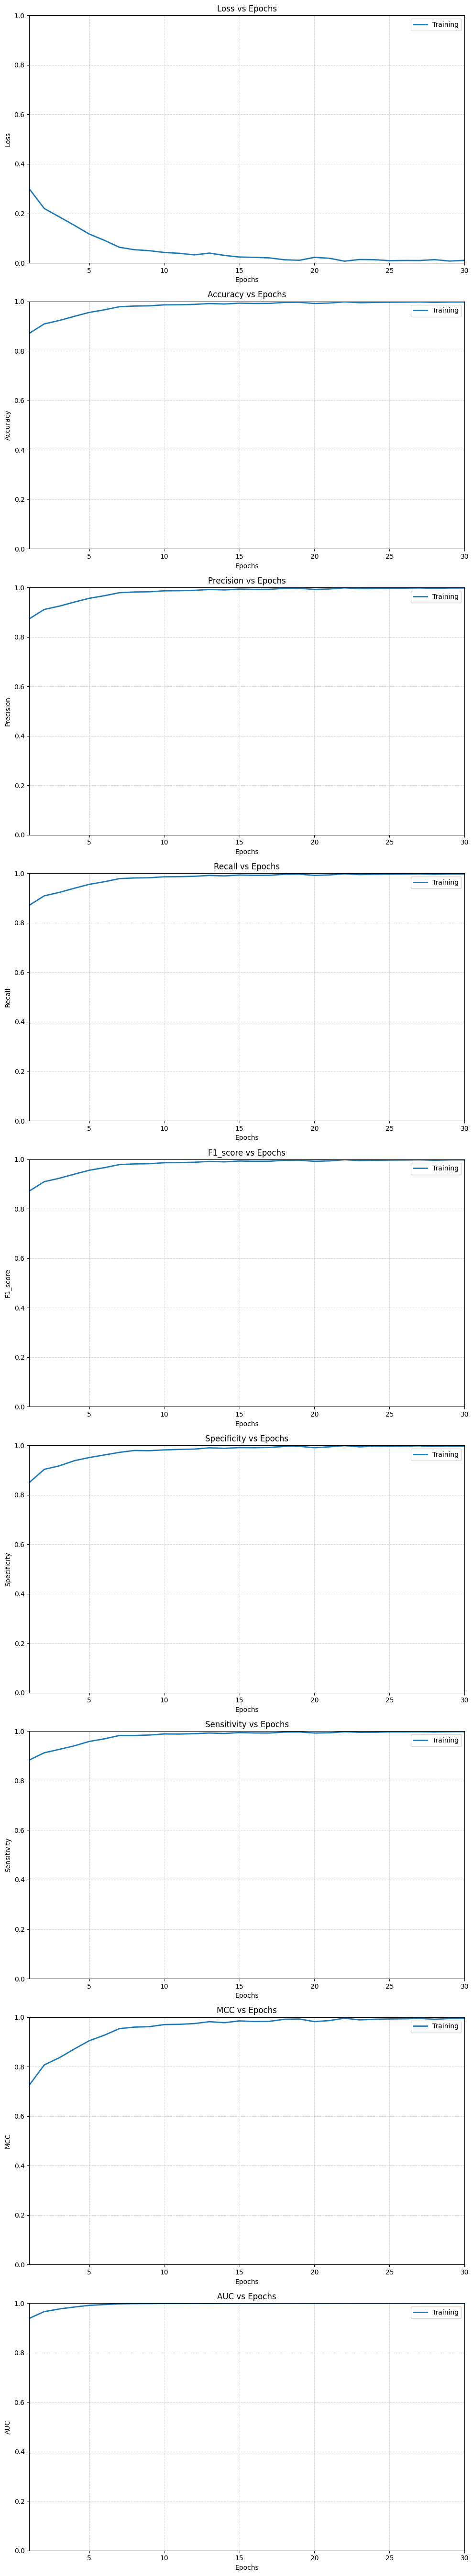

In [27]:
plot_metrics(train_metrics_history, metric_names)

In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import numpy as np

# --------------------------------------------------
# Convert predictions to class labels
# --------------------------------------------------

true_labels = np.array(all_test_targets).astype(int)

predicted_labels = np.argmax(
    np.array(all_test_predictions),
    axis=1
).astype(int)

# --------------------------------------------------
# Class names
# --------------------------------------------------

class_names = [
    "Normal",
    "Pneumonia"
]

# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("="*70)
print("CLASSIFICATION REPORT")
print("="*70)

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
)

print(report)

# --------------------------------------------------
# Accuracy
# --------------------------------------------------

accuracy = accuracy_score(
    true_labels,
    predicted_labels
)

print(f"\nAccuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("\nConfusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN : {tn}")
print(f"FP : {fp}")
print(f"FN : {fn}")
print(f"TP : {tp}")

# --------------------------------------------------
# Sensitivity & Specificity
# --------------------------------------------------

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nSensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal     0.9628    0.9166    0.9391       791
   Pneumonia     0.9697    0.9869    0.9782      2137

    accuracy                         0.9679      2928
   macro avg     0.9662    0.9517    0.9587      2928
weighted avg     0.9678    0.9679    0.9676      2928


Accuracy : 0.9679 (96.79%)

Confusion Matrix
[[ 725   66]
 [  28 2109]]

TN : 725
FP : 66
FN : 28
TP : 2109

Sensitivity : 0.9869
Specificity : 0.9166
